In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wkirgsn/electric-motor-temperature")

print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/datasets/wkirgsn/electric-motor-temperature


In [7]:
import os
import pandas as pd
    
df = pd.read_csv('/kaggle/input/datasets/wkirgsn/electric-motor-temperature/measures_v2.csv', nrows=5)

print(df.columns.tolist())

['u_q', 'coolant', 'stator_winding', 'u_d', 'stator_tooth', 'motor_speed', 'i_d', 'i_q', 'pm', 'stator_yoke', 'ambient', 'torque', 'profile_id']


In [8]:
# ==========================================================
# STEP 1 - LOAD AND VALIDATE PMSM DATASET
# ==========================================================

import pandas as pd
import numpy as np

# -----------------------------
# Dataset Path
# -----------------------------
DATA_PATH = "/kaggle/input/datasets/wkirgsn/electric-motor-temperature/measures_v2.csv"

print("=" * 60)
print("Loading PMSM Dataset...")
print("=" * 60)

# Load using float32 to reduce memory
df = pd.read_csv(DATA_PATH, dtype=np.float32)

print("\nDataset Loaded Successfully.\n")

# --------------------------------------------------
# Basic Information
# --------------------------------------------------
print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

# --------------------------------------------------
# Column Names
# --------------------------------------------------
print("\nColumns")

print(df.columns.tolist())

# --------------------------------------------------
# Data Types
# --------------------------------------------------
print("\nData Types")

print(df.dtypes)

# --------------------------------------------------
# Missing Values
# --------------------------------------------------
print("\nMissing Values")

missing = df.isnull().sum()

print(missing)

print(f"\nTotal Missing Values : {missing.sum():,}")

# --------------------------------------------------
# Duplicate Rows
# --------------------------------------------------
duplicates = df.duplicated().sum()

print(f"\nDuplicate Rows : {duplicates:,}")

# --------------------------------------------------
# Memory Usage
# --------------------------------------------------
memory_mb = df.memory_usage(deep=True).sum() / 1024**2

print(f"\nMemory Usage : {memory_mb:.2f} MB")

# --------------------------------------------------
# Statistical Summary
# --------------------------------------------------
print("\nSummary Statistics")

print(df.describe().T)

# --------------------------------------------------
# Verify Required Columns
# --------------------------------------------------

required_columns = [
    "u_q",
    "coolant",
    "stator_winding",
    "u_d",
    "stator_tooth",
    "motor_speed",
    "i_d",
    "i_q",
    "pm",
    "stator_yoke",
    "ambient",
    "torque",
    "profile_id"
]

missing_columns = list(set(required_columns) - set(df.columns))

if len(missing_columns) == 0:
    print("\n✅ Dataset validation successful.")
else:
    print("\n❌ Missing columns:")
    print(missing_columns)

print("\nStep 1 Completed Successfully.")

Loading PMSM Dataset...

Dataset Loaded Successfully.

Dataset Shape
Rows    : 1,330,816
Columns : 13

Columns
['u_q', 'coolant', 'stator_winding', 'u_d', 'stator_tooth', 'motor_speed', 'i_d', 'i_q', 'pm', 'stator_yoke', 'ambient', 'torque', 'profile_id']

Data Types
u_q               float32
coolant           float32
stator_winding    float32
u_d               float32
stator_tooth      float32
motor_speed       float32
i_d               float32
i_q               float32
pm                float32
stator_yoke       float32
ambient           float32
torque            float32
profile_id        float32
dtype: object

Missing Values
u_q               0
coolant           0
stator_winding    0
u_d               0
stator_tooth      0
motor_speed       0
i_d               0
i_q               0
pm                0
stator_yoke       0
ambient           0
torque            0
profile_id        0
dtype: int64

Total Missing Values : 0

Duplicate Rows : 0

Memory Usage : 66.00 MB

Summary Statistics


In [9]:
# ==========================================================
# STEP 2 - PHYSICS-AWARE DATA CLEANING
# ==========================================================

import numpy as np
import pandas as pd

print("="*60)
print("STEP 2 : DATA CLEANING")
print("="*60)

# --------------------------------------------------------
# Initial shape
# --------------------------------------------------------

print(f"\nInitial Shape : {df.shape}")

# --------------------------------------------------------
# Remove Duplicate Rows
# --------------------------------------------------------

duplicate_rows = df.duplicated().sum()

print(f"\nDuplicate Rows Found : {duplicate_rows}")

if duplicate_rows > 0:
    df = df.drop_duplicates()

print(f"Shape After Duplicate Removal : {df.shape}")

# --------------------------------------------------------
# Replace Infinite Values
# --------------------------------------------------------

df.replace([np.inf, -np.inf], np.nan, inplace=True)

# --------------------------------------------------------
# Remove Missing Values
# --------------------------------------------------------

missing_before = df.isna().sum().sum()

print(f"\nMissing Values Before Cleaning : {missing_before}")

df.dropna(inplace=True)

missing_after = df.isna().sum().sum()

print(f"Missing Values After Cleaning : {missing_after}")

print(f"Shape After NaN Removal : {df.shape}")

# --------------------------------------------------------
# Sort by Driving Profile
# --------------------------------------------------------

df = df.sort_values(by="profile_id").reset_index(drop=True)

print("\nDataset Sorted by profile_id")

# --------------------------------------------------------
# Physical Range Checks
# --------------------------------------------------------

print("\nChecking Physical Ranges")

physical_limits = {
    "motor_speed": (-20000, 20000),
    "u_d": (-500, 500),
    "u_q": (-500, 500),
    "i_d": (-1000, 1000),
    "i_q": (-1000, 1000),
    "torque": (-500, 500),
    "ambient": (-50, 100),
    "coolant": (-50, 150),
    "pm": (-50, 250),
    "stator_yoke": (-50, 250),
    "stator_tooth": (-50, 250),
    "stator_winding": (-50, 250)
}

for column, (low, high) in physical_limits.items():

    outside = ((df[column] < low) | (df[column] > high)).sum()

    print(f"{column:18s} -> {outside:8d} suspicious values")

print("\nCleaning Completed.")

print(f"\nCurrent Dataset Shape : {df.shape}")

STEP 2 : DATA CLEANING

Initial Shape : (1330816, 13)

Duplicate Rows Found : 0
Shape After Duplicate Removal : (1330816, 13)

Missing Values Before Cleaning : 0
Missing Values After Cleaning : 0
Shape After NaN Removal : (1330816, 13)

Dataset Sorted by profile_id

Checking Physical Ranges
motor_speed        ->        0 suspicious values
u_d                ->        0 suspicious values
u_q                ->        0 suspicious values
i_d                ->        0 suspicious values
i_q                ->        0 suspicious values
torque             ->        0 suspicious values
ambient            ->        0 suspicious values
coolant            ->        0 suspicious values
pm                 ->        0 suspicious values
stator_yoke        ->        0 suspicious values
stator_tooth       ->        0 suspicious values
stator_winding     ->        0 suspicious values

Cleaning Completed.

Current Dataset Shape : (1330816, 13)


In [10]:
# ==========================================================
# STEP 3 - PHYSICS-BASED FEATURE ENGINEERING
# ==========================================================

import numpy as np

print("=" * 60)
print("STEP 3 : PHYSICS FEATURE ENGINEERING")
print("=" * 60)

# --------------------------------------------------------
# Motor Parameters
# --------------------------------------------------------

Rs = 0.05        # Nominal stator resistance (Ohm)

# --------------------------------------------------------
# Current Magnitude
# --------------------------------------------------------

df["current_mag"] = np.sqrt(df["i_d"]**2 + df["i_q"]**2)

# --------------------------------------------------------
# Voltage Magnitude
# --------------------------------------------------------

df["voltage_mag"] = np.sqrt(df["u_d"]**2 + df["u_q"]**2)

# --------------------------------------------------------
# Electrical Input Power
# --------------------------------------------------------

df["electrical_power"] = (
    df["u_d"] * df["i_d"] +
    df["u_q"] * df["i_q"]
)

# --------------------------------------------------------
# Apparent Power
# --------------------------------------------------------

df["apparent_power"] = (
    df["voltage_mag"] *
    df["current_mag"]
)

# --------------------------------------------------------
# Copper Loss
# --------------------------------------------------------

df["copper_loss"] = (
    1.5 *
    Rs *
    (
        df["i_d"]**2 +
        df["i_q"]**2
    )
)

# --------------------------------------------------------
# Average Stator Temperature
# --------------------------------------------------------

df["avg_stator_temp"] = (
    df["stator_winding"] +
    df["stator_tooth"] +
    df["stator_yoke"]
) / 3.0

# --------------------------------------------------------
# Temperature Difference
# --------------------------------------------------------

df["stator_coolant_delta"] = (
    df["avg_stator_temp"] -
    df["coolant"]
)

# --------------------------------------------------------
# PM Temperature Difference
# --------------------------------------------------------

df["pm_ambient_delta"] = (
    df["pm"] -
    df["ambient"]
)

# --------------------------------------------------------
# Torque Constant Estimate
# --------------------------------------------------------

epsilon = 1e-6

df["torque_constant"] = (
    df["torque"] /
    (df["current_mag"] + epsilon)
)

# --------------------------------------------------------
# Current Vector Angle
# --------------------------------------------------------

df["current_angle"] = np.arctan2(
    df["i_q"],
    df["i_d"]
)

# --------------------------------------------------------
# Voltage Vector Angle
# --------------------------------------------------------

df["voltage_angle"] = np.arctan2(
    df["u_q"],
    df["u_d"]
)

# --------------------------------------------------------
# Estimated Efficiency Proxy
# --------------------------------------------------------

df["efficiency_proxy"] = (
    df["electrical_power"] /
    (df["electrical_power"] +
     df["copper_loss"] +
     epsilon)
)

# --------------------------------------------------------
# Display New Features
# --------------------------------------------------------

print("\nNew Features Added")

new_features = [
    "current_mag",
    "voltage_mag",
    "electrical_power",
    "apparent_power",
    "copper_loss",
    "avg_stator_temp",
    "stator_coolant_delta",
    "pm_ambient_delta",
    "torque_constant",
    "current_angle",
    "voltage_angle",
    "efficiency_proxy"
]

for feature in new_features:
    print(feature)

print("\nTotal Features:", len(df.columns))

print("\nCurrent Dataset Shape:", df.shape)

STEP 3 : PHYSICS FEATURE ENGINEERING

New Features Added
current_mag
voltage_mag
electrical_power
apparent_power
copper_loss
avg_stator_temp
stator_coolant_delta
pm_ambient_delta
torque_constant
current_angle
voltage_angle
efficiency_proxy

Total Features: 25

Current Dataset Shape: (1330816, 25)


In [11]:
# ==========================================================
# STEP 4 - PROFILE SPLIT + FEATURE SCALING
# Memory-Efficient Version
# ==========================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

print("=" * 70)
print("STEP 4 : PROFILE SPLIT + FEATURE SCALING")
print("=" * 70)

# ----------------------------------------------------------
# Configuration
# ----------------------------------------------------------

RANDOM_STATE = 42

TARGET_COLUMNS = [
    "pm",
    "stator_winding",
    "stator_tooth",
    "stator_yoke"
]

FEATURE_COLUMNS = [
    c for c in df.columns
    if c not in TARGET_COLUMNS + ["profile_id"]
]

print(f"\nNumber of Features : {len(FEATURE_COLUMNS)}")
print(f"Number of Targets  : {len(TARGET_COLUMNS)}")

# ----------------------------------------------------------
# Unique Profiles
# ----------------------------------------------------------

profiles = df["profile_id"].unique()

print(f"\nTotal Profiles : {len(profiles)}")

if len(profiles) < 3:
    raise ValueError(
        f"Only {len(profiles)} unique profile(s) found. "
        "Reload the full dataset before continuing."
    )

# ----------------------------------------------------------
# Train / Validation / Test Split
# ----------------------------------------------------------

train_profiles, temp_profiles = train_test_split(
    profiles,
    test_size=0.30,
    random_state=RANDOM_STATE,
    shuffle=True
)

valid_profiles, test_profiles = train_test_split(
    temp_profiles,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True
)

print("\nProfiles")

print("Train :", len(train_profiles))
print("Valid :", len(valid_profiles))
print("Test  :", len(test_profiles))

# ----------------------------------------------------------
# Split DataFrames
# ----------------------------------------------------------

train_df = (
    df[df["profile_id"].isin(train_profiles)]
    .copy()
    .reset_index(drop=True)
)

valid_df = (
    df[df["profile_id"].isin(valid_profiles)]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    df[df["profile_id"].isin(test_profiles)]
    .copy()
    .reset_index(drop=True)
)

print("\nDataset Sizes")

print("Train :", train_df.shape)
print("Valid :", valid_df.shape)
print("Test  :", test_df.shape)

# ----------------------------------------------------------
# Safety Check
# ----------------------------------------------------------

assert len(train_df) > 0
assert len(valid_df) > 0
assert len(test_df) > 0

# ----------------------------------------------------------
# Standardization
# ----------------------------------------------------------

scaler = StandardScaler()

scaler.fit(train_df[FEATURE_COLUMNS])

train_df.loc[:, FEATURE_COLUMNS] = scaler.transform(
    train_df[FEATURE_COLUMNS]
)

valid_df.loc[:, FEATURE_COLUMNS] = scaler.transform(
    valid_df[FEATURE_COLUMNS]
)

test_df.loc[:, FEATURE_COLUMNS] = scaler.transform(
    test_df[FEATURE_COLUMNS]
)

# ----------------------------------------------------------
# Save Scaler
# ----------------------------------------------------------

joblib.dump(
    scaler,
    "feature_scaler.pkl"
)

print("\nScaler saved as feature_scaler.pkl")

# ----------------------------------------------------------
# Leakage Check
# ----------------------------------------------------------

assert (
    set(train_profiles)
    .intersection(set(valid_profiles))
    == set()
)

assert (
    set(train_profiles)
    .intersection(set(test_profiles))
    == set()
)

assert (
    set(valid_profiles)
    .intersection(set(test_profiles))
    == set()
)

print("\nNo Profile Leakage Detected")

# ----------------------------------------------------------
# Display Statistics
# ----------------------------------------------------------

print("\nTraining Feature Means")

print(
    train_df[FEATURE_COLUMNS]
    .mean()
    .round(4)
)

print("\nTraining Feature Standard Deviations")

print(
    train_df[FEATURE_COLUMNS]
    .std()
    .round(4)
)

print("\nSTEP 4 COMPLETED SUCCESSFULLY")

STEP 4 : PROFILE SPLIT + FEATURE SCALING

Number of Features : 20
Number of Targets  : 4

Total Profiles : 69

Profiles
Train : 48
Valid : 10
Test  : 11

Dataset Sizes
Train : (879860, 25)
Valid : (217136, 25)
Test  : (233820, 25)


/tmp/ipykernel_58/2979059598.py:119: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.04935608 -1.04935115 -1.04937926 ... -1.23455627 -1.23432941
 -1.23412839]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  train_df.loc[:, FEATURE_COLUMNS] = scaler.transform(
/tmp/ipykernel_58/2979059598.py:119: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.76605188 -0.77203202 -0.77393929 ...  2.1030809   2.10284054
  2.10299212]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  train_df.loc[:, FEATURE_COLUMNS] = scaler.transform(
/tmp/ipykernel_58/2979059598.py:119: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.30011486 0.30002282 0.30006426 ... 0.37350097 0.37237423 0.3747805 ]' has dtype inco


Scaler saved as feature_scaler.pkl

No Profile Leakage Detected

Training Feature Means
u_q                    -0.0
coolant                 0.0
u_d                     0.0
motor_speed             0.0
i_d                     0.0
i_q                    -0.0
ambient                 0.0
torque                 -0.0
current_mag             0.0
voltage_mag             0.0
electrical_power        0.0
apparent_power          0.0
copper_loss            -0.0
avg_stator_temp         0.0
stator_coolant_delta    0.0
pm_ambient_delta        0.0
torque_constant        -0.0
current_angle          -0.0
voltage_angle           0.0
efficiency_proxy        0.0
dtype: float64

Training Feature Standard Deviations
u_q                     1.0
coolant                 1.0
u_d                     1.0
motor_speed             1.0
i_d                     1.0
i_q                     1.0
ambient                 1.0
torque                  1.0
current_mag             1.0
voltage_mag             1.0
electrical_power  

In [15]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ==========================================================
# STEP 5 : MEMORY-EFFICIENT DATASET
# ==========================================================

class PMSMDataset(Dataset):

    def __init__(
        self,
        dataframe,
        feature_columns,
        target_columns,
        sequence_length=64
    ):

        self.sequence_length = sequence_length

        # Store one copy of each profile
        self.profile_data = {}

        # Index: (profile_id, start_index)
        self.indices = []

        profiles = sorted(dataframe["profile_id"].unique())

        print(f"Preparing {len(profiles)} profiles...")

        total_windows = 0

        for profile in profiles:

            profile_df = dataframe[
                dataframe["profile_id"] == profile
            ].reset_index(drop=True)

            if len(profile_df) <= sequence_length:
                continue

            features = profile_df[
                feature_columns
            ].to_numpy(dtype=np.float32)

            targets = profile_df[
                target_columns
            ].to_numpy(dtype=np.float32)

            self.profile_data[profile] = (
                features,
                targets
            )

            n_windows = len(profile_df) - sequence_length

            for start in range(n_windows):
                self.indices.append(
                    (profile, start)
                )

            total_windows += n_windows

        print(f"Total Windows : {total_windows:,}")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):

        profile, start = self.indices[idx]

        features, targets = self.profile_data[profile]

        x = features[
            start:start+self.sequence_length
        ]

        y = targets[
            start+self.sequence_length
        ]

        return (
            torch.from_numpy(x),
            torch.from_numpy(y)
        )

In [16]:
WINDOW_SIZE = 64

train_dataset = PMSMDataset(
    train_df,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
    sequence_length=WINDOW_SIZE
)

valid_dataset = PMSMDataset(
    valid_df,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
    sequence_length=WINDOW_SIZE
)

test_dataset = PMSMDataset(
    test_df,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
    sequence_length=WINDOW_SIZE
)

Preparing 48 profiles...
Total Windows : 876,788
Preparing 10 profiles...
Total Windows : 216,496
Preparing 11 profiles...
Total Windows : 233,116


In [17]:
# ==========================================================
# STEP 6 : CNN BASELINE MODEL
# ==========================================================

import torch
import torch.nn as nn

class CNNRegressor(nn.Module):

    def __init__(self, input_features=20, output_features=4):

        super().__init__()

        self.feature_extractor = nn.Sequential(

            nn.Conv1d(
                in_channels=input_features,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.MaxPool1d(2),

            ###################################################

            nn.Conv1d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.MaxPool1d(2),

            ###################################################

            nn.Conv1d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(256),

            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)

        )

        self.regressor = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256,128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128,64),

            nn.ReLU(),

            nn.Linear(64,output_features)

        )

    def forward(self,x):

        # x shape
        # (Batch, Sequence, Features)

        x = x.permute(0,2,1)

        x = self.feature_extractor(x)

        x = self.regressor(x)

        return x

In [18]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CNNRegressor(
    input_features=len(FEATURE_COLUMNS),
    output_features=len(TARGET_COLUMNS)
).to(device)

print(model)

CNNRegressor(
  (feature_extractor): Sequential(
    (0): Conv1d(20, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_fea

In [19]:
from torch.utils.data import DataLoader

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

In [12]:
X_batch, Y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)

prediction = model(X_batch)

print("Input :", X_batch.shape)

print("Prediction :", prediction.shape)

print("Target :", Y_batch.shape)

Input : torch.Size([128, 64, 20])
Prediction : torch.Size([128, 4])
Target : torch.Size([128, 4])


In [20]:
import torch
import torch.nn as nn

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
model = CNNRegressor(
    input_features=len(FEATURE_COLUMNS),
    output_features=len(TARGET_COLUMNS)
).to(device)

# Loss Function
criterion = nn.MSELoss()

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

# Training Parameters
EPOCHS = 30
BATCH_SIZE = 128

print(device)
print("Model Ready")

cuda
Model Ready


In [21]:
import time
import copy
import torch
import numpy as np
from tqdm.auto import tqdm

# ==========================================================
# COMPLETE TRAINING FUNCTION
# ==========================================================

def train_model(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=50,
    model_name="best_model.pth"
):

    print("=" * 70)
    print("TRAINING STARTED")
    print("=" * 70)

    model = model.to(device)

    best_loss = float("inf")
    best_weights = copy.deepcopy(model.state_dict())

    train_history = []
    valid_history = []

    # Mixed Precision (GPU only)
    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    start_time = time.time()

    for epoch in range(epochs):

        ############################################################
        # TRAIN
        ############################################################

        model.train()

        running_loss = 0.0

        train_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{epochs}",
            leave=True
        )

        for X_batch, Y_batch in train_bar:

            X_batch = X_batch.to(device, non_blocking=True)
            Y_batch = Y_batch.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                predictions = model(X_batch)
                loss = criterion(predictions, Y_batch)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

            train_bar.set_postfix(
                loss=f"{loss.item():.5f}"
            )

        train_loss = running_loss / len(train_loader)

        ############################################################
        # VALIDATION
        ############################################################

        model.eval()

        running_val_loss = 0.0

        valid_bar = tqdm(
            valid_loader,
            desc="Validation",
            leave=False
        )

        with torch.no_grad():

            for X_batch, Y_batch in valid_bar:

                X_batch = X_batch.to(device, non_blocking=True)
                Y_batch = Y_batch.to(device, non_blocking=True)

                with torch.amp.autocast("cuda", enabled=use_amp):
                    predictions = model(X_batch)
                    loss = criterion(predictions, Y_batch)

                running_val_loss += loss.item()

                valid_bar.set_postfix(
                    val_loss=f"{loss.item():.5f}"
                )

        valid_loss = running_val_loss / len(valid_loader)

        scheduler.step(valid_loss)

        train_history.append(train_loss)
        valid_history.append(valid_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"\nEpoch {epoch+1:03d}/{epochs}"
            f" | Train={train_loss:.6f}"
            f" | Valid={valid_loss:.6f}"
            f" | LR={current_lr:.6e}"
        )

        ############################################################
        # SAVE BEST MODEL
        ############################################################

        if valid_loss < best_loss:

            best_loss = valid_loss

            best_weights = copy.deepcopy(model.state_dict())

            torch.save(best_weights, model_name)

            print("✓ Best model saved")

    ############################################################
    # FINISHED
    ############################################################

    total_minutes = (time.time() - start_time) / 60

    model.load_state_dict(best_weights)

    print("\n" + "=" * 70)
    print("TRAINING FINISHED")
    print("=" * 70)

    print(f"Best Validation Loss : {best_loss:.6f}")
    print(f"Training Time        : {total_minutes:.2f} minutes")

    return model, train_history, valid_history

MODEL TRAINING

In [44]:
trained_model, train_loss, valid_loss = train_model(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=50,
    model_name="cnn_best.pth"
)

TRAINING STARTED


Epoch 1/50:   0%|          | 0/6850 [00:00<?, ?it/s]

Validation:   0%|          | 0/1692 [00:00<?, ?it/s]


Epoch 001/50 | Train=51.751498 | Valid=154.341503 | LR=1.000000e-03
✓ Best model saved


Epoch 2/50:   0%|          | 0/6850 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1692 [00:00<?, ?it/s]


Epoch 049/50 | Train=2.455464 | Valid=186.275655 | LR=3.906250e-06


Epoch 50/50:   0%|          | 0/6850 [00:00<?, ?it/s]

Validation:   0%|          | 0/1692 [00:00<?, ?it/s]


Epoch 050/50 | Train=2.452960 | Valid=187.903096 | LR=3.906250e-06

TRAINING FINISHED
Best Validation Loss : 154.341503
Training Time        : 49.41 minutes


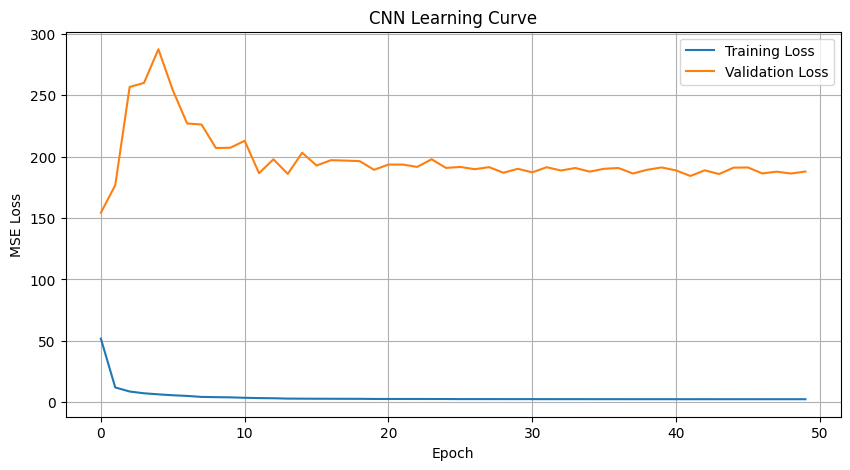

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train_loss, label="Training Loss")
plt.plot(valid_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CNN Learning Curve")

plt.grid(True)
plt.legend()

plt.show()

In [23]:
import torch
import torch.nn as nn

# ==========================================================
# LSTM REGRESSOR
# ==========================================================

class LSTMRegressor(nn.Module):

    def __init__(
        self,
        input_features=20,
        hidden_size=128,
        num_layers=2,
        dropout=0.3,
        output_features=4
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.regressor = nn.Sequential(

            nn.Linear(hidden_size,128),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(128,64),

            nn.ReLU(),

            nn.Linear(64,output_features)

        )

    def forward(self,x):

        out, (hidden, cell) = self.lstm(x)

        x = hidden[-1]

        x = self.regressor(x)

        return x

In [22]:
import torch
import torch.nn as nn

# ==========================================================
# TRANSFORMER REGRESSOR
# ==========================================================

class TransformerRegressor(nn.Module):

    def __init__(
        self,
        input_features=20,
        d_model=128,
        nhead=8,
        num_layers=4,
        dropout=0.1,
        output_features=4
    ):

        super().__init__()

        self.embedding = nn.Linear(
            input_features,
            d_model
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1,64,d_model)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.regressor = nn.Sequential(

            nn.Linear(d_model,128),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(128,64),

            nn.ReLU(),

            nn.Linear(64,output_features)

        )

    def forward(self,x):

        x = self.embedding(x)

        x = x + self.pos_embedding[:, :x.size(1), :]

        x = self.transformer(x)

        x = torch.mean(x,dim=1)

        x = self.regressor(x)

        return x

In [24]:
import torch
import torch.nn as nn

# ==========================================================
# PROPOSED HYBRID CNN-ViT
# ==========================================================

class CNNViTRegressor(nn.Module):

    def __init__(
        self,
        input_features=20,
        output_features=4,
        d_model=128,
        heads=8,
        transformer_layers=4,
        dropout=0.3
    ):

        super().__init__()

        ##################################################
        # CNN BRANCH
        ##################################################

        self.cnn = nn.Sequential(

            nn.Conv1d(input_features,64,kernel_size=3,padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64,128,kernel_size=3,padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128,128,kernel_size=3,padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)

        )

        ##################################################
        # ViT BRANCH
        ##################################################

        self.embedding = nn.Linear(
            input_features,
            d_model
        )

        self.position_embedding = nn.Parameter(
            torch.randn(1,64,d_model)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=heads,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=transformer_layers
        )

        ##################################################
        # FEATURE FUSION
        ##################################################

        self.fusion = nn.Sequential(

            nn.Linear(256,256),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(256,128),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(128,output_features)

        )

    #########################################################

    def forward(self,x):

        ############################################
        # CNN
        ############################################

        cnn_x = x.transpose(1,2)

        cnn_feat = self.cnn(cnn_x)

        cnn_feat = cnn_feat.squeeze(-1)

        ############################################
        # ViT
        ############################################

        vit = self.embedding(x)

        vit = vit + self.position_embedding[:, :x.size(1)]

        vit = self.transformer(vit)

        vit_feat = vit.mean(dim=1)

        ############################################
        # Fusion
        ############################################

        fused = torch.cat(
            [cnn_feat,vit_feat],
            dim=1
        )

        out = self.fusion(fused)

        return out

In [43]:
import torch
import torch.nn as nn
import gc
import os


# ==========================================================
# COMMON TRAINING CONFIGURATION
# ==========================================================

EPOCHS = 50

LR = 1e-3

WEIGHT_DECAY = 1e-4


input_features = 20
output_features = 4



# ==========================================================
# MODEL FACTORY
# ==========================================================

def create_model(model_name):

    if model_name == "CNN":

        return CNNRegressor(
            input_features=input_features,
            output_features=output_features
        )


    elif model_name == "LSTM":

        return LSTMRegressor(
            input_features=input_features,
            output_features=output_features
        )


    elif model_name == "Transformer":

        return TransformerRegressor(
            input_features=input_features,
            output_features=output_features
        )


    elif model_name == "CNN_ViT":

        return CNNViTRegressor(
            input_features=input_features,
            output_features=output_features
        )


    else:

        raise ValueError(
            "Unknown model"
        )



In [18]:


# ==========================================================
# TRAIN CONFIGURATION
# ==========================================================

models_to_train = [

    "CNN",

    "LSTM",

    "Transformer",

    "CNN_ViT"

]



# ==========================================================
# NORMAL DATA-DRIVEN TRAINING
# ==========================================================

for model_name in models_to_train:


    print("\n")
    print("="*80)
    print(
        f"TRAINING BASELINE {model_name}"
    )
    print("="*80)



    model = create_model(
        model_name
    )


    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )


    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5
    )


    criterion = nn.MSELoss()



    trained_model, train_loss, valid_loss = train_model(

        model=model,

        train_loader=train_loader,

        valid_loader=valid_loader,

        criterion=criterion,

        optimizer=optimizer,

        scheduler=scheduler,

        device=device,

        epochs=EPOCHS,

        model_name=f"{model_name}_baseline_best.pth"

    )


    del model

    gc.collect()

    torch.cuda.empty_cache()



print("\nALL BASELINE MODELS COMPLETE")



TRAINING BASELINE LSTM
TRAINING STARTED


Epoch 1/50:   0%|          | 0/6850 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [25]:
import torch
import torch.nn as nn

# ==========================================================
# EV PHYSICS MODEL
# ==========================================================

class EVPhysics(nn.Module):

    def __init__(self):

        super().__init__()

        self.Rs0 = 0.05
        self.alpha = 0.00393
        self.coolant = 40.0

    def forward(
        self,
        prediction,
        inputs
    ):

        """
        prediction
        ----------
        pm
        stator_winding
        stator_tooth
        stator_yoke

        inputs
        ------
        i_d
        i_q
        """

        pm = prediction[:,0]

        winding = prediction[:,1]

        tooth = prediction[:,2]

        yoke = prediction[:,3]

        id_current = inputs[:,:,4][:,-1]

        iq_current = inputs[:,:,5][:,-1]

        ###################################################
        # Resistance
        ###################################################

        Rs = self.Rs0 * (
            1 +
            self.alpha *
            (winding - 20)
        )

        ###################################################
        # Copper Loss
        ###################################################

        copper_loss = 1.5 * Rs * (
            id_current**2 +
            iq_current**2
        )

        ###################################################
        # Thermal Gradient
        ###################################################

        thermal_gradient = (
            winding -
            self.coolant
        )

        return {

            "Rs":Rs,

            "CopperLoss":copper_loss,

            "ThermalGradient":thermal_gradient

        }

In [26]:
class PhysicsLoss(nn.Module):

    def __init__(self):

        super().__init__()

        self.mse = nn.MSELoss()


    def forward(
        self,
        prediction,
        target,
        physics
    ):


        # --------------------------------
        # Data prediction loss
        # --------------------------------

        data_loss = self.mse(
            prediction,
            target
        )


        # --------------------------------
        # Physics penalties
        # --------------------------------

        copper_loss = torch.mean(
            physics["CopperLoss"]
        )


        thermal_gradient_loss = torch.mean(

            torch.relu(
                -physics["ThermalGradient"]
            )

        )


        # --------------------------------
        # Total scalar loss
        # --------------------------------

        total_loss = (

            data_loss

            +

            0.01 * copper_loss

            +

            0.05 * thermal_gradient_loss

        )


        return total_loss

In [28]:
#Training Engine
import os
import copy
import torch
from tqdm.auto import tqdm

In [29]:
class EarlyStopping:

    def __init__(

        self,

        patience=10,

        min_delta=1e-5

    ):

        self.patience = patience

        self.min_delta = min_delta

        self.counter = 0

        self.best_loss = float("inf")

        self.early_stop = False


    def __call__(

        self,

        validation_loss

    ):

        if validation_loss < self.best_loss - self.min_delta:

            self.best_loss = validation_loss

            self.counter = 0

        else:

            self.counter += 1

            print(

                f"EarlyStopping "

                f"{self.counter}/{self.patience}"

            )

            if self.counter >= self.patience:

                self.early_stop = True

In [30]:
@torch.no_grad()

def validate(

    model,

    physics_model,

    loader,

    criterion,

    device

):

    model.eval()

    total_loss = 0


    for X,Y in loader:

        X = X.to(device)

        Y = Y.to(device)


        prediction = model(X)


        physics = physics_model(

            prediction,

            X

        )


        loss = criterion(

            prediction,

            Y,

            physics

        )


        total_loss += loss.item()


    return (

        total_loss /

        len(loader)

    )

In [31]:
def save_checkpoint(

    checkpoint_path,

    epoch,

    model,

    optimizer,

    scheduler,

    best_loss,

    train_loss,

    valid_loss

):

    torch.save({

        "epoch": epoch,

        "best_loss": best_loss,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "scheduler_state_dict": scheduler.state_dict(),

        "train_loss": train_loss,

        "valid_loss": valid_loss

    }, checkpoint_path)

In [32]:
@torch.no_grad()

def validate(

    model,

    physics_model,

    loader,

    criterion,

    device

):

    model.eval()

    running_loss = 0

    for X,Y in loader:

        X = X.to(device)

        Y = Y.to(device)

        prediction = model(X)

        physics = physics_model(

            prediction,

            X

        )

        loss = criterion(

            prediction,

            Y,

            physics

        )

        running_loss += loss.item()

    return running_loss / len(loader)

In [33]:
def train_one_epoch(
    model,
    physics_model,
    train_loader,
    criterion,
    optimizer,
    device
):
    """
    Train the model for ONE epoch.

    Returns
    -------
    average_train_loss : float
    """

    model.train()

    running_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc="Training",
        leave=False
    )

    for X_batch, Y_batch in train_bar:

        # ---------------------------------------
        # Move data to GPU
        # ---------------------------------------
        X_batch = X_batch.to(
            device,
            non_blocking=True
        )

        Y_batch = Y_batch.to(
            device,
            non_blocking=True
        )

        # ---------------------------------------
        # Zero gradients
        # ---------------------------------------
        optimizer.zero_grad()

        # ---------------------------------------
        # Forward pass
        # ---------------------------------------
        prediction = model(X_batch)

        # ---------------------------------------
        # Physics engine
        # ---------------------------------------
        physics = physics_model(
            prediction,
            X_batch
        )

        # ---------------------------------------
        # Compute physics-informed loss
        # ---------------------------------------
        loss = criterion(
            prediction,
            Y_batch,
            physics
        )

        # ---------------------------------------
        # Backpropagation
        # ---------------------------------------
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    average_train_loss = running_loss / len(train_loader)

    return average_train_loss

In [34]:
# ==========================================================
# Physics-Informed Training Engine
# Compatible with existing checkpoints
# ==========================================================

def train_physics_engine(

    model,
    physics_model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs,
    experiment_name

):

    """
    Physics-informed training engine.

    Features
    --------
    ✓ Resume interrupted training
    ✓ Validation every epoch
    ✓ LR scheduler
    ✓ Best model saving
    ✓ Checkpoint saving
    ✓ Early stopping
    """

    # ----------------------------------------------------
    # Move models to device
    # ----------------------------------------------------

    model = model.to(device)

    physics_model = physics_model.to(device)

    # ----------------------------------------------------
    # File names
    # ----------------------------------------------------

    checkpoint_path = experiment_name + "_checkpoint.pth"

    best_model_path = experiment_name + "_best.pth"

    # ----------------------------------------------------
    # Resume training if checkpoint exists
    # ----------------------------------------------------

    start_epoch, best_loss, train_history, valid_history = load_checkpoint(

        checkpoint_path,

        model,

        optimizer,

        scheduler,

        device

    )

    # ----------------------------------------------------
    # Early stopping
    # ----------------------------------------------------

    early_stopping = EarlyStopping(
        patience=8
    )

    # ----------------------------------------------------
    # Main Training Loop
    # ----------------------------------------------------

    for epoch in range(start_epoch, epochs):

        print("\n")
        print("=" * 60)
        print(f"Epoch {epoch+1}/{epochs}")
        print("=" * 60)

        # ------------------------------------------------
        # Training
        # ------------------------------------------------

        train_loss = train_one_epoch(

            model=model,

            physics_model=physics_model,

            train_loader=train_loader,

            criterion=criterion,

            optimizer=optimizer,

            device=device

        )

        # ------------------------------------------------
        # Validation
        # ------------------------------------------------

        valid_loss = validate(

            model=model,

            physics_model=physics_model,

            loader=valid_loader,

            criterion=criterion,

            device=device

        )

        # ------------------------------------------------
        # Scheduler
        # ------------------------------------------------

        scheduler.step(valid_loss)

        # ------------------------------------------------
        # Store history
        # ------------------------------------------------

        train_history.append(train_loss)

        valid_history.append(valid_loss)

        # ------------------------------------------------
        # Print losses
        # ------------------------------------------------

        print(f"Train Loss : {train_loss:.6f}")

        print(f"Valid Loss : {valid_loss:.6f}")

        # ------------------------------------------------
        # Save Best Model
        # ------------------------------------------------

        if valid_loss < best_loss:

            best_loss = valid_loss

            torch.save(

                model.state_dict(),

                best_model_path

            )

            print("✓ Best model updated.")

        # ------------------------------------------------
        # Save checkpoint
        # ------------------------------------------------

        save_checkpoint(

            checkpoint_path,

            epoch,

            model,

            optimizer,

            scheduler,

            best_loss,

            train_history,

            valid_history

        )

        print("✓ Checkpoint saved.")

        # ------------------------------------------------
        # Early stopping
        # ------------------------------------------------

        early_stopping(valid_loss)

        if early_stopping.early_stop:

            print("\nEarly stopping triggered.")
            print("Training stopped due to no validation improvement.")

            break

    # ----------------------------------------------------
    # Training completed
    # ----------------------------------------------------

    print("\nTraining Finished.")

    return (

        model,

        train_history,

        valid_history

    )

In [36]:
def run_all_physics_models(

    train_loader,

    valid_loader,

    device,

    epochs=30

):
    """
    Train all physics-informed models.

    Models:
        Physics CNN
        Physics LSTM
        Physics Transformer
        Physics CNN-ViT
    """

    physics_results = {}

    models = [

        # "CNN",

        # "LSTM",

        "Transformer",

        "CNN_ViT"

    ]

    for model_name in models:

        print("\n")
        print("="*80)
        print(f"Training Physics {model_name}")
        print("="*80)

        # ---------------------------------------
        # Create Neural Network
        # ---------------------------------------

        model = create_model(model_name)

        # ---------------------------------------
        # Physics Engine
        # ---------------------------------------

        physics_model = EVPhysics()

        # ---------------------------------------
        # Physics Loss
        # ---------------------------------------

        criterion = PhysicsLoss()

        # ---------------------------------------
        # Optimizer
        # ---------------------------------------

        optimizer = torch.optim.AdamW(

            model.parameters(),

            lr=1e-3,

            weight_decay=1e-4

        )

        # ---------------------------------------
        # Scheduler
        # ---------------------------------------

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

            optimizer,

            mode="min",

            factor=0.5,

            patience=5

        )

        # ---------------------------------------
        # Train
        # ---------------------------------------

        trained_model, train_loss, valid_loss = train_physics_engine(

            model=model,

            physics_model=physics_model,

            train_loader=train_loader,

            valid_loader=valid_loader,

            criterion=criterion,

            optimizer=optimizer,

            scheduler=scheduler,

            device=device,

            epochs=epochs,

            experiment_name=f"Physics_{model_name}"

        )

        physics_results[model_name] = {

            "train_loss": train_loss,

            "valid_loss": valid_loss

        }

        # ---------------------------------------
        # Free GPU Memory
        # ---------------------------------------

        del model
        del physics_model
        del trained_model

        gc.collect()

        torch.cuda.empty_cache()

    print("\n")
    print("="*80)
    print("ALL PHYSICS MODELS FINISHED")
    print("="*80)

    return physics_results

In [37]:
physics_results = run_all_physics_models(

    train_loader=train_loader,

    valid_loader=valid_loader,

    device=device,

    epochs=30

)



Training Physics Transformer


Epoch 1/30


Training:   0%|          | 0/6850 [00:00<?, ?it/s]

Train Loss : 25.391952
Valid Loss : 22.889768
✓ Best model updated.
✓ Checkpoint saved.


Epoch 2/30


Training:   0%|          | 0/6850 [00:00<?, ?it/s]

Train Loss : 3.277591
Valid Loss : 32.517412
✓ Checkpoint saved.
EarlyStopping 1/8


Epoch 3/30


...

Training:   0%|          | 0/6850 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ebebdf81260>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ebebdf81260>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Train Loss : 11.481077
Valid Loss : 4.404183
✓ Checkpoint saved.
EarlyStopping 1/8


Epoch 30/30


Training:   0%|          | 0/6850 [00:00<?, ?it/s]

Train Loss : 11.395348
Valid Loss : 3.664642
✓ Checkpoint saved.
EarlyStopping 2/8

Training Finished.


ALL PHYSICS MODELS FINISHED


In [38]:
for model, result in physics_results.items():

    print("=" * 50)
    print(model)

    print("Final Train Loss :", result["train_loss"][-1])

    print("Final Valid Loss :", result["valid_loss"][-1])

    print("Best Valid Loss  :", min(result["valid_loss"]))

Transformer
Final Train Loss : 2.130246790377763
Final Valid Loss : 29.454045767620663
Best Valid Loss  : 22.889768095022117
CNN_ViT
Final Train Loss : 11.395347791448996
Final Valid Loss : 3.6646418487895325
Best Valid Loss  : 2.9846711679263787


In [39]:
import os

for root, dirs, files in os.walk("/kaggle"):
    for f in files:
        if f.endswith(".pth"):
            print(os.path.join(root, f))

/kaggle/working/Physics_Transformer_checkpoint.pth
/kaggle/working/Physics_CNN_ViT_best.pth
/kaggle/working/Physics_CNN_ViT_checkpoint.pth
/kaggle/working/Physics_Transformer_best.pth


In [40]:
import numpy as np
import torch

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluate_model(
    model,
    test_loader,
    device
):

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for X, Y in test_loader:

            X = X.to(device)
            Y = Y.to(device)

            pred = model(X)

            predictions.append(
                pred.cpu().numpy()
            )

            targets.append(
                Y.cpu().numpy()
            )

    predictions = np.concatenate(predictions, axis=0)

    targets = np.concatenate(targets, axis=0)

    mae = mean_absolute_error(
        targets,
        predictions
    )

    mse = mean_squared_error(
        targets,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        targets,
        predictions
    )

    mape = np.mean(
        np.abs(
            (targets - predictions) /
            (targets + 1e-8)
        )
    ) * 100

    return {

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "MAPE": mape,

        "R2": r2

    }

In [41]:
model = CNNViTRegressor(
    input_features=20,
    output_features=4
)

model.load_state_dict(
    torch.load(
        "Physics_CNN_ViT_best.pth",
        map_location=device
    )
)

model.to(device)

metrics = evaluate_model(
    model,
    test_loader,
    device
)

print(metrics)

{'MAE': 0.9869191646575928, 'MSE': 2.612877368927002, 'RMSE': np.float64(1.6164397201649685), 'MAPE': np.float32(2.0220683), 'R2': 0.9956983327865601}


In [45]:
model = TransformerRegressor(
    input_features=20,
    output_features=4
)

model.load_state_dict(
    torch.load(
        "Physics_Transformer_best.pth",
        map_location=device
    )
)

model.to(device)

metrics = evaluate_model(
    model,
    test_loader,
    device
)

print(metrics)

{'MAE': 4.564272403717041, 'MSE': 25.965360641479492, 'RMSE': np.float64(5.095621712949215), 'MAPE': np.float32(8.034351), 'R2': 0.9474302530288696}


In [40]:
#for fraction 25%, 50%, 75%
def run_all_physics_models(

    train_loader,

    valid_loader,

    device,

    data_size=None,

    epochs=30

):
    """
    Train all Physics-Informed Models.

    Parameters
    ----------
    train_loader : DataLoader
        Training loader for the selected data fraction.

    valid_loader : DataLoader
        Validation loader.

    data_size : str
        Example:
            "25%"
            "50%"
            "75%"
            "100%"
    """

    physics_results = {}

    models = [

        "CNN",

        #"LSTM",

        # "Transformer",

        # "CNN_ViT"

    ]

    for model_name in models:

        print("\n")
        print("=" * 80)
        print(f"Training Physics {model_name} ({data_size})")
        print("=" * 80)

        # ----------------------------------------------------
        # Create Neural Model
        # ----------------------------------------------------

        model = create_model(model_name)

        # ----------------------------------------------------
        # Physics Model
        # ----------------------------------------------------

        physics_model = EVPhysics()

        # ----------------------------------------------------
        # Physics Loss
        # ----------------------------------------------------

        criterion = PhysicsLoss()

        # ----------------------------------------------------
        # Optimizer
        # ----------------------------------------------------

        optimizer = torch.optim.AdamW(

            model.parameters(),

            lr=1e-3,

            weight_decay=1e-4

        )

        # ----------------------------------------------------
        # Scheduler
        # ----------------------------------------------------

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

            optimizer,

            mode="min",

            factor=0.5,

            patience=5

        )

        # ----------------------------------------------------
        # Unique experiment name
        # ----------------------------------------------------

        experiment_name = f"Physics_{model_name}_{data_size}"

        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        trained_model, train_loss, valid_loss = train_physics_engine(

            model=model,

            physics_model=physics_model,

            train_loader=train_loader,

            valid_loader=valid_loader,

            criterion=criterion,

            optimizer=optimizer,

            scheduler=scheduler,

            device=device,

            epochs=epochs,

            experiment_name=experiment_name

        )

        physics_results[experiment_name] = {

            "train_loss": train_loss,

            "valid_loss": valid_loss

        }

        # ----------------------------------------------------
        # Free GPU Memory
        # ----------------------------------------------------

        del model
        del physics_model
        del trained_model

        gc.collect()

        torch.cuda.empty_cache()

    print("\n")
    print("=" * 80)
    print(f"ALL PHYSICS MODELS COMPLETED ({data_size})")
    print("=" * 80)

    return physics_results

In [36]:
from torch.utils.data import random_split, DataLoader
import torch

# ==========================================================
# Create 25%, 50%, 75%, 100% datasets
# ==========================================================

dataset_size = len(train_dataset)

sizes = {

    "25%": int(dataset_size * 0.25),

    "50%": int(dataset_size * 0.50),

    "75%": int(dataset_size * 0.75),

    "100%": dataset_size

}

train_loaders = {}

for name, size in sizes.items():

    if size == dataset_size:

        subset = train_dataset

    else:

        subset, _ = random_split(

            train_dataset,

            [size, dataset_size - size],

            generator=torch.Generator().manual_seed(42)

        )

    train_loaders[name] = DataLoader(

        subset,

        batch_size=BATCH_SIZE,

        shuffle=True,

        num_workers=2,

        pin_memory=True

    )

print("Created loaders:")

print(train_loaders.keys())

Created loaders:
dict_keys(['25%', '50%', '75%', '100%'])


In [38]:
import os
import torch

# ==========================================================
# Save checkpoint
# ==========================================================

def save_checkpoint(
    checkpoint_path,
    epoch,
    model,
    optimizer,
    scheduler,
    best_loss,
    train_history,
    valid_history
):

    checkpoint = {

        "epoch": epoch,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "scheduler_state_dict": scheduler.state_dict(),

        "best_loss": best_loss,

        "train_history": train_history,

        "valid_history": valid_history

    }

    torch.save(checkpoint, checkpoint_path)


# ==========================================================
# Load checkpoint
# ==========================================================

def load_checkpoint(

    checkpoint_path,

    model,

    optimizer,

    scheduler,

    device

):

    if os.path.exists(checkpoint_path):

        print("Resuming previous training...")

        checkpoint = torch.load(

            checkpoint_path,

            map_location=device

        )

        model.load_state_dict(

            checkpoint["model_state_dict"]

        )

        optimizer.load_state_dict(

            checkpoint["optimizer_state_dict"]

        )

        scheduler.load_state_dict(

            checkpoint["scheduler_state_dict"]

        )

        start_epoch = checkpoint["epoch"] + 1

        best_loss = checkpoint["best_loss"]

        train_history = checkpoint["train_history"]

        valid_history = checkpoint["valid_history"]

    else:

        print("Starting new training...")

        start_epoch = 0

        best_loss = float("inf")

        train_history = []

        valid_history = []

    return (

        start_epoch,

        best_loss,

        train_history,

        valid_history

    )

In [39]:
names = [
    "EarlyStopping",
    "load_checkpoint",
    "save_checkpoint",
    "train_one_epoch",
    "validate"
]

for n in names:
    print(f"{n}: {'✓ Defined' if n in globals() else '✗ NOT defined'}")

EarlyStopping: ✓ Defined
load_checkpoint: ✓ Defined
save_checkpoint: ✓ Defined
train_one_epoch: ✓ Defined
validate: ✓ Defined


In [44]:
#For fraction data

physics_results = {}

for data_size, loader in train_loaders.items():

    physics_results[data_size] = run_all_physics_models(

        train_loader=loader,

        valid_loader=valid_loader,

        device=device,

        data_size=data_size,

        epochs=30

    )



Training Physics CNN (25%)
Starting new training...


Epoch 1/30


Training:   0%|          | 0/1713 [00:00<?, ?it/s]

Train Loss : 112.733129
Valid Loss : 10.161854
✓ Best model updated.
✓ Checkpoint saved.


Epoch 2/30


Training:   0%|          | 0/1713 [00:00<?, ?it/s]

Train Loss : 35.488986
Valid Loss : 9.917278
✓ Best model updated.
✓ Checkpoint saved.


Epoch 3/30


...

Train Loss : 4.557059
Valid Loss : 251.037780
✓ Checkpoint saved.
EarlyStopping 6/8


Epoch 8/30


Training:   0%|          | 0/6850 [00:00<?, ?it/s]

Train Loss : 3.870036
Valid Loss : 266.752562
✓ Checkpoint saved.
EarlyStopping 7/8


Epoch 9/30


Training:   0%|          | 0/6850 [00:00<?, ?it/s]

Train Loss : 3.732362
Valid Loss : 276.217414
✓ Checkpoint saved.
EarlyStopping 8/8

Early stopping triggered.
Training stopped due to no validation improvement.

Training Finished.


ALL PHYSICS MODELS COMPLETED (100%)


In [45]:
import os

for f in os.listdir("/kaggle/working"):
    if f.endswith("_best.pth"):
        print(f)

Physics_CNN_75%_best.pth
Physics_CNN_25%_best.pth
Physics_CNN_50%_best.pth
Physics_CNN_100%_best.pth


In [47]:
import os
import zipfile
import glob

zip_filename = "/kaggle/working/Physics_Models.zip"

# Remove old zip if it exists
if os.path.exists(zip_filename):
    os.remove(zip_filename)

# Create zip
with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zipf:

    for file in glob.glob("/kaggle/working/*.pth"):

        zipf.write(
            file,
            arcname=os.path.basename(file)
        )

print("===================================")
print("ZIP created successfully!")
print(zip_filename)
print("===================================")

print("\nFiles included:")

for file in glob.glob("/kaggle/working/*.pth"):
    print(os.path.basename(file))

ZIP created successfully!
/kaggle/working/Physics_Models.zip

Files included:
Physics_CNN_25%_checkpoint.pth
Physics_CNN_100%_checkpoint.pth
Physics_CNN_75%_best.pth
Physics_CNN_25%_best.pth
Physics_CNN_50%_best.pth
Physics_CNN_50%_checkpoint.pth
Physics_CNN_100%_best.pth
Physics_CNN_75%_checkpoint.pth


In [48]:
from IPython.display import FileLink

FileLink("/kaggle/working/Physics_Models.zip")

/kaggle/working/Physics_Models.zip

In [50]:
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluate_model(
    model,
    test_loader,
    device
):

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for X, Y in test_loader:

            X = X.to(device)

            Y = Y.to(device)

            pred = model(X)

            predictions.append(
                pred.cpu().numpy()
            )

            targets.append(
                Y.cpu().numpy()
            )

    predictions = np.concatenate(predictions, axis=0)

    targets = np.concatenate(targets, axis=0)

    mae = mean_absolute_error(
        targets,
        predictions
    )

    mse = mean_squared_error(
        targets,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        targets,
        predictions
    )

    mape = np.mean(

        np.abs(

            (targets - predictions)

            /

            (targets + 1e-8)

        )

    ) * 100

    return {

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "MAPE": mape,

        "R2": r2

    }

In [51]:
import os

results = []

fractions = [

    "25%",

    "50%",

    "75%",

    "100%"

]

for fraction in fractions:

    filename = f"Physics_CNN_{fraction}_best.pth"

    if not os.path.exists(filename):

        print(f"{filename} not found.")

        continue

    print(f"Loading {filename}")

    model = CNNRegressor(

        input_features=20,

        output_features=4

    )

    model.load_state_dict(

        torch.load(

            filename,

            map_location=device

        )

    )

    model.to(device)

    metrics = evaluate_model(

        model,

        test_loader,

        device

    )

    metrics["Model"] = "Physics CNN"

    metrics["Training Fraction"] = fraction

    results.append(metrics)

Loading Physics_CNN_25%_best.pth
Loading Physics_CNN_50%_best.pth
Loading Physics_CNN_75%_best.pth
Loading Physics_CNN_100%_best.pth


In [52]:
results_df = pd.DataFrame(results)

results_df = results_df[

    [

        "Model",

        "Training Fraction",

        "MAE",

        "MSE",

        "RMSE",

        "MAPE",

        "R2"

    ]

]

print(results_df)

         Model Training Fraction        MAE         MSE       RMSE       MAPE  \
0  Physics CNN               25%   2.052186    9.631396   3.103449   3.631272   
1  Physics CNN               50%   8.289806   89.065948   9.437476  13.821795   
2  Physics CNN               75%   6.652389   57.166203   7.560833  11.239659   
3  Physics CNN              100%  11.597249  173.267502  13.163111  18.295572   

         R2  
0  0.982759  
1  0.822414  
2  0.883622  
3  0.669617  
